Referencing/attempting this paper: [text](<../../Downloads/School/UROC/Induction motor speed control using reduced-order model.pdf>)

$$
i_{sd}=\text{d-axis stator current},\quad
i_{sq}=\text{q-axis stator current},
$$

$$
\phi_{rd}=\text{d-axis rotor flux},\quad
\phi_{rq}=\text{q-axis rotor flux},
$$

$$
\Omega=\text{rotor mechanical speed}
$$

$$
x=
\begin{bmatrix}
i_{sd}\\
i_{sq}\\
\phi_{rd}\\
\phi_{rq}\\
\Omega
\end{bmatrix}
$$

$$
u=
\begin{bmatrix}
v_{sd}\\
v_{sq}\\
T_l
\end{bmatrix}
$$

$$
y=
\begin{bmatrix}
i_{sd}\\
i_{sq}
\end{bmatrix}
$$

$$
\dot{i}_{sd}
=
-\gamma i_{sd}
+\omega_s i_{sq}
+ba\phi_{rd}
+bp\phi_{rq}
+m_1v_{sd}
$$

$$
\dot{i}_{sq}
=
-\omega_si_{sd}
-\gamma i_{sq}
-bp\phi_{rd}
+ba\phi_{rq}
+m_1v_{sq}
$$

$$
\dot{\phi}_{rd}
=
aM_{sr}i_{sd}
-a\phi_{rd}
+(\omega_s-p)\phi_{rq}
$$

$$
\dot{\phi}_{rq}
=
aM_{sr}i_{sq}
-(\omega_s-p)\phi_{rd}
-a\phi_{rq}
$$

$$
\dot{\Omega}
=
m(\phi_{rd}i_{sq}-\phi_{rq}i_{sd})
-c
-\frac{T_l}{J}
$$

$$
a=\frac{R_r}{L_r}
$$

$$
b=\frac{M_{sr}}{\sigma L_sL_r}
$$

$$
c=\frac{f_v}{J}
$$

$$
\gamma=
\frac{L_r^{2}R_s+M_{sr}^{2}R_r}
{\sigma L_sL_r^{2}}
$$

$$
\sigma=
1-\frac{M_{sr}^{2}}{L_sL_r}
$$

$$
m=
\frac{pM_{sr}}{JL_r}
$$

$$
m_1=
\frac{1}{\sigma L_s}
$$

Reduce Simple wasn't able to mimic the original graphs stated in the paper because they change t=200, at 1 second, so I'm trying to manually simulate the orginal system using ode.int below

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

#Motor parameters
Rs = 0.087       # stator resistance, ohms
Rr = 0.228       # rotor resistance, ohms
Ls = 0.0355      # stator inductance, H
Lr = 0.0355      # rotor inductance, H
Msr = 0.0347     # mutual inductance, H
J = 1.662        # rotor inertia, kg·m^2
fv = 0.1         # viscous friction coefficient
p = 2            # number of pole pairs

#operating conditions
omega_s = 377.0  # synchronous electrical speed, rad/s

# Convert 460 V line-to-line RMS into phase peak voltage
V_phase_peak = np.sqrt(2) * 460 / np.sqrt(3)

vsd = V_phase_peak
vsq = 0.0

#auxiliary constants
sigma = 1 - Msr**2 / (Ls * Lr)

a = Rr / Lr
b = Msr / (sigma * Ls * Lr)
c = fv / J

gamma = (
    Lr**2 * Rs + Msr**2 * Rr
) / (
    sigma * Ls * Lr**2
)

m = p * Msr / (J * Lr)
m1 = 1 / (sigma * Ls)

#time-dependent load torque

def load_torque(t):
    """Apply 200 N·m at and after 1 second. """
    return 0.0 if t < 1.0 else 200.0

#full 5th-order motor model
def motor_ode(state, t):
    """state = [isd, isq, phird, phirq, Omega]"""

    # Unpack current state
    isd, isq, phird, phirq, Omega = state

    # Get the load torque at this time
    Tl = load_torque(t)

    # Slip speed
    slip = omega_s - p * Omega

    # d-axis current derivative
    disd_dt = (
        -gamma * isd
        + omega_s * isq
        + b * a * phird
        + b * p * Omega * phirq
        + m1 * vsd
    )

    # q-axis current derivative
    disq_dt = (
        -omega_s * isd
        - gamma * isq
        - b * p * Omega * phird
        + b * a * phirq
        + m1 * vsq
    )

    # d-axis rotor-flux derivative
    dphird_dt = (
        a * Msr * isd
        - a * phird
        + slip * phirq
    )

    # q-axis rotor-flux derivative
    dphirq_dt = (
        a * Msr * isq
        - slip * phird
        - a * phirq
    )

    # Rotor-speed derivative
    dOmega_dt = (
        m * (phird * isq - phirq * isd)
        - c * Omega
        - Tl / J
    )

    return [
        disd_dt,
        disq_dt,
        dphird_dt,
        dphirq_dt,
        dOmega_dt
    ]


#initial conditions
initial_state = np.zeros(5)

# Equivalent to:
# [isd, isq, phird, phirq, Omega] = [0, 0, 0, 0, 0]

#simulation conditions
time = np.linspace(0, 2, 4001)

#solve the ODE system
solution, solver_info = odeint(
    motor_ode,
    initial_state,
    time,
    full_output=True,
    rtol=1e-8,
    atol=1e-10,
    mxstep=20000
)

print(solver_info["message"])


#extact the states
isd = solution[:, 0]
isq = solution[:, 1]
phird = solution[:, 2]
phirq = solution[:, 3]
Omega = solution[:, 4]

Integration successful.


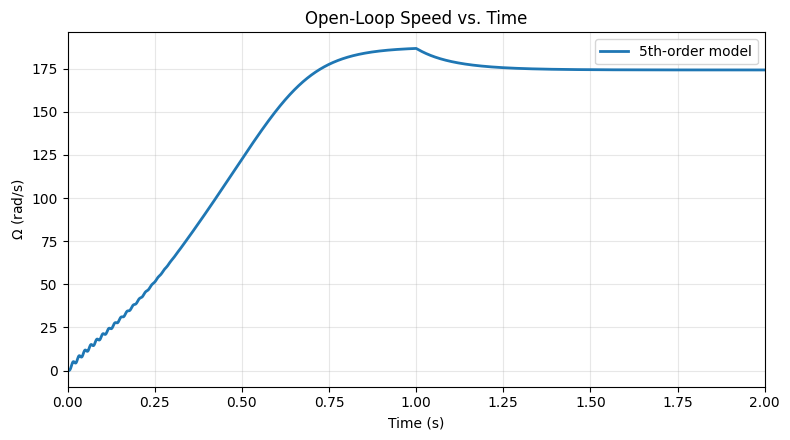

In [14]:
#plot the rotor speed
plt.figure(figsize=(8, 4.5))

plt.plot(
    time,
    Omega,
    linewidth=2,
    label="5th-order model"
)

# plt.axvline(
#     1.0,
#     linestyle=":",
#     linewidth=1.5,
#     label=r"$T_L$ changes to 200 N·m"
# )

plt.xlabel("Time (s)")
plt.ylabel(r"$\Omega$ (rad/s)")
plt.title("Open-Loop Speed vs. Time")
plt.xlim(0, 2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

For the simulated original system, we didn't utlize autoreduce, so we have to manually extract the symbolic equations

In [15]:
# #Code allows for symbolic representation of the system of equations. This is useful for analysis and control design.
# gamma_s, omega_s_sym, b_s, a_s, p_s = sp.symbols(
#     r"\gamma \omega_s b a p"
# )

# m1_s, vsd_s, vsq_s, Msr_s = sp.symbols(
#     r"m_1 v_{sd} v_{sq} M_{sr}"
# )

# m_s, c_s, J_s = sp.symbols(
#     r"m c J"
# )

# f_general = [
#     -gamma_s * isd_s
#     + omega_s_sym * isq_s
#     + b_s * a_s * phird_s
#     + b_s * p_s * Omega_s * phirq_s
#     + m1_s * vsd_s,

#     -omega_s_sym * isd_s
#     - gamma_s * isq_s
#     - b_s * p_s * Omega_s * phird_s
#     + b_s * a_s * phirq_s
#     + m1_s * vsq_s,

#     a_s * Msr_s * isd_s
#     - a_s * phird_s
#     + (omega_s_sym - p_s * Omega_s) * phirq_s,

#     a_s * Msr_s * isq_s
#     - (omega_s_sym - p_s * Omega_s) * phird_s
#     - a_s * phirq_s,

#     m_s * (phird_s * isq_s - phirq_s * isd_s)
#     - c_s * Omega_s
#     - Tl_s / J_s
# ]

# display(
#     Math(
#         r"\dot{\mathbf{x}}="
#         + sp.latex(sp.Matrix(f_general))
#     )
# )

In [16]:
import sympy as sp
from IPython.display import display, Math

# Symbolic states
isd_s, isq_s = sp.symbols("i_sd i_sq")
phird_s, phirq_s = sp.symbols(r"\phi_rd \phi_rq")
Omega_s = sp.symbols(r"\Omega")
Tl_s = sp.symbols("T_l")

# Symbolic state vector
state_symbols = [
    isd_s,
    isq_s,
    phird_s,
    phirq_s,
    Omega_s
]

# Symbolic equations with numeric parameters
f_symbolic = [
    -gamma * isd_s
    + omega_s * isq_s
    + b * a * phird_s
    + b * p * Omega_s * phirq_s
    + m1 * vsd,

    -omega_s * isd_s
    - gamma * isq_s
    - b * p * Omega_s * phird_s
    + b * a * phirq_s
    + m1 * vsq,

    a * Msr * isd_s
    - a * phird_s
    + (omega_s - p * Omega_s) * phirq_s,

    a * Msr * isq_s
    - (omega_s - p * Omega_s) * phird_s
    - a * phirq_s,

    m * (phird_s * isq_s - phirq_s * isd_s)
    - c * Omega_s
    - Tl_s / J
]

In [17]:
from sympy import latex

display(
    Math(
        r"\text{Original System: } "
        + latex(f_symbolic)
    )
)

<IPython.core.display.Math object>

Used skeleton code to match states above, output is c[0][4], rotor speed, since the paper compares reduced models based on how well they preserve speed, adjusted p[9]-p[11]= to 0 to accurate reproduce the open-loop graphs 

The first code block uses `odeint` to simulate the original motor model and verify that it matches the results in the paper.

The second code block (below) recreates the same equations in AutoReduce. AutoReduce requires symbolic equations (`sys.f`) instead of a numerical simulation so it can generate reduced-order models.

changed params_values[9] = np.sqrt(2) * 460 / np.sqrt(3) instead of 0

In [18]:
from autoreduce import *
import numpy as np
import matplotlib.pyplot as plt

# Motor model
n = 5
nouts = 1

# States
# x[0] = isd
# x[1] = isq
# x[2] = phird
# x[3] = phirq
# x[4] = Omega

# Parameters
# P[0]  = Rs
# P[1]  = Rr
# P[2]  = Ls
# P[3]  = Lr
# P[4]  = Msr
# P[5]  = J
# P[6]  = fv
# P[7]  = p
# P[8]  = omega_s
# P[9]  = vsd
# P[10] = vsq
# P[11] = Tl

P = np.zeros(12)

P[0] = 0.087
P[1] = 0.228
P[2] = 0.0355
P[3] = 0.0355
P[4] = 0.0347
P[5] = 1.662
P[6] = 0.1
P[7] = 2.0
P[8] = 377.0
P[9] = np.sqrt(2) * 460 / np.sqrt(3)
P[10] = 0.0
P[11] = 200.0

params_values = P.copy()
timepoints_ode = np.linspace(0, 2, 4001)

# Initial states
x_init = np.zeros(n)

# Symbolic states and parameters
x, f, P = load_ODE_model(n, len(params_values))
params = P

# Short names
Rs = P[0]
Rr = P[1]
Ls = P[2]
Lr = P[3]
Msr = P[4]
J = P[5]
fv = P[6]
p = P[7]
omega_s = P[8]
vsd = P[9]
vsq = P[10]
Tl = P[11]

isd = x[0]
isq = x[1]
phird = x[2]
phirq = x[3]
Omega = x[4]

# Auxiliary constants
sigma = 1 - Msr**2 / (Ls * Lr)

a = Rr / Lr
b = Msr / (sigma * Ls * Lr)
c = fv / J

gamma = (
    Lr**2 * Rs + Msr**2 * Rr
) / (
    sigma * Ls * Lr**2
)

m = p * Msr / (J * Lr)
m1 = 1 / (sigma * Ls)

slip = omega_s - p * Omega

# Motor ODEs
f[0] = (
    -gamma * isd
    + omega_s * isq
    + b * a * phird
    + b * p * Omega * phirq
    + m1 * vsd
)

f[1] = (
    -omega_s * isd
    - gamma * isq
    - b * p * Omega * phird
    + b * a * phirq
    + m1 * vsq
)

f[2] = (
    a * Msr * isd
    - a * phird
    + slip * phirq
)

f[3] = (
    a * Msr * isq
    - slip * phird
    - a * phirq
)

f[4] = (
    m * (phird * isq - phirq * isd)
    - c * Omega
    - Tl / J
)

# Output: Omega
C = np.zeros((nouts, len(x)), dtype=int)
C[0][4] = 1
C = C.tolist()

sys = System(
    x,
    f,
    params=params,
    C=C,
    params_values=params_values,
    x_init=x_init
)

In [19]:
try:
    import seaborn as sn
    for j in range(nouts):
        sn.heatmap(out_Ss[:,:,j].T)
        plt.xlabel('Time')
        plt.ylabel('Parameters')
        plt.title('Sensitivity of output[{0}] with respect to all parameters'.format(j))
        plt.show()
except:
    print('Plotting libraries missing.')

Plotting libraries missing.


.reduce_simple() even with skipping all the parameters don't work, it gets stuck in an infinite loop or error.

In [20]:
from autoreduce.utils import get_reducible
timepoints_ssm = np.linspace(0,60,10)
timepoints_ode = np.linspace(0, 2, 100)
sys_reduce = get_reducible(sys, timepoints_ode, timepoints_ssm)
#results = sys_reduce.reduce_simple(skip_numerical_computation = True,skip_error_computation = True, skip_robustness_computation = True)
#results = sys_reduce.reduce_simple()

After manually solving the orignal ODE model (while keeping in mind the change in torque), manually computing the reduced models using .solve_timescale_separation. 

In [ ]:
# 1-state reductions
# reduced_system_1d1, _ = sys_reduce.solve_timescale_separation([x[0]])  # retain isd
# reduced_system_1d2, _ = sys_reduce.solve_timescale_separation([x[1]])  # retain isq
# reduced_system_1d3, _ = sys_reduce.solve_timescale_separation([x[2]])  # retain phird
# reduced_system_1d4, _ = sys_reduce.solve_timescale_separation([x[3]])  # retain phirq
# reduced_system_1d5, _ = sys_reduce.solve_timescale_separation([x[4]])  # retain Omega


# 2-state reductions
# reduced_system_2d1, _ = sys_reduce.solve_timescale_separation([x[0], x[1]])  # retain isd, isq
# reduced_system_2d2, _ = sys_reduce.solve_timescale_separation([x[0], x[2]])  # retain isd, phird
# reduced_system_2d3, _ = sys_reduce.solve_timescale_separation([x[0], x[3]])  # retain isd, phirq
reduced_system_2d4, _ = sys_reduce.solve_timescale_separation([x[0], x[4]])  # retain isd, Omega
# reduced_system_2d5, _ = sys_reduce.solve_timescale_separation([x[1], x[2]])  # retain isq, phird
# reduced_system_2d6, _ = sys_reduce.solve_timescale_separation([x[1], x[3]])  # retain isq, phirq
reduced_system_2d7, _ = sys_reduce.solve_timescale_separation([x[1], x[4]])  # retain isq, Omega
# reduced_system_2d8, _ = sys_reduce.solve_timescale_separation([x[2], x[3]])  # retain phird, phirq
# ?reduced_system_2d9, _ = sys_reduce.solve_timescale_separation([x[2], x[4]])  # retain phird, Omega !!!? paper works
# ?reduced_system_2d10, _ = sys_reduce.solve_timescale_separation([x[3], x[4]])  # retain phirq, Omega


# 3-state reductions
reduced_system_3d1, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[2]])  # retain isd, isq, phird
reduced_system_3d2, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[3]])  # retain isd, isq, phirq
reduced_system_3d3, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[4]])  # retain isd, isq, Omega
reduced_system_3d4, _ = sys_reduce.solve_timescale_separation([x[0], x[2], x[3]])  # retain isd, phird, phirq
reduced_system_3d5, _ = sys_reduce.solve_timescale_separation([x[0], x[2], x[4]])  # retain isd, phird, Omega
reduced_system_3d6, _ = sys_reduce.solve_timescale_separation([x[0], x[3], x[4]])  # retain isd, phirq, Omega
reduced_system_3d7, _ = sys_reduce.solve_timescale_separation([x[1], x[2], x[3]])  # retain isq, phird, phirq
reduced_system_3d8, _ = sys_reduce.solve_timescale_separation([x[1], x[2], x[4]])  # retain isq, phird, Omega
reduced_system_3d9, _ = sys_reduce.solve_timescale_separation([x[1], x[3], x[4]])  # retain isq, phirq, Omega
reduced_system_3d10, _ = sys_reduce.solve_timescale_separation([x[2], x[3], x[4]])  # retain phird, phirq, Omega This is the third order reduction that is used in the paper.


# 4-state reductions
reduced_system_4d1, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[2], x[3]])  # retain isd, isq, phird, phirq
reduced_system_4d2, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[2], x[4]])  # retain isd, isq, phird, Omega
reduced_system_4d3, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[3], x[4]])  # retain isd, isq, phirq, Omega
reduced_system_4d4, _ = sys_reduce.solve_timescale_separation([x[0], x[2], x[3], x[4]])  # retain isd, phird, phirq, Omega
reduced_system_4d5, _ = sys_reduce.solve_timescale_separation([x[1], x[2], x[3], x[4]])  # retain isq, phird, phirq, Omega

Successful solution obtained with states: [x0, x4]!
Successful solution obtained with states: [x1, x4]!
Successful solution obtained with states: [x0, x1, x2]!
Successful solution obtained with states: [x0, x1, x3]!
Successful solution obtained with states: [x0, x1, x4]!
Successful solution obtained with states: [x0, x2, x3]!
Successful solution obtained with states: [x0, x2, x4]!
Successful solution obtained with states: [x0, x3, x4]!
Successful solution obtained with states: [x1, x2, x3]!
Successful solution obtained with states: [x1, x2, x4]!
Successful solution obtained with states: [x1, x3, x4]!
Successful solution obtained with states: [x2, x3, x4]!
Successful solution obtained with states: [x0, x1, x2, x3]!
Successful solution obtained with states: [x0, x1, x2, x4]!
Successful solution obtained with states: [x0, x1, x3, x4]!
Successful solution obtained with states: [x0, x2, x3, x4]!
Successful solution obtained with states: [x1, x2, x3, x4]!


In [22]:
#this code Makes the Latex display of the original system and the system with the parameters a,b,c, gamma, m, m1. It also displays the equations for each state in the system.

# from IPython.display import display, Math
# from sympy import latex

# display(Math(r"\text{Original System}"))

# state_names = [
#     r"\dot{i}_{sd}",
#     r"\dot{i}_{sq}",
#     r"\dot{\phi}_{rd}",
#     r"\dot{\phi}_{rq}",
#     r"\dot{\Omega}"
# ]

# for name, equation in zip(state_names, sys.f):
#     display(Math(name + " = " + latex(equation)))

# a_s, b_s, c_s = sp.symbols("a b c")
# gamma_s, m_s, m1_s = sp.symbols(r"\gamma m m_1")

# display_f = [
#     -gamma_s * x[0]
#     + P[8] * x[1]
#     + b_s * a_s * x[2]
#     + b_s * P[7] * x[4] * x[3]
#     + m1_s * P[9],

#     -P[8] * x[0]
#     - gamma_s * x[1]
#     - b_s * P[7] * x[4] * x[2]
#     + b_s * a_s * x[3]
#     + m1_s * P[10],

#     a_s * P[4] * x[0]
#     - a_s * x[2]
#     + (P[8] - P[7] * x[4]) * x[3],

#     a_s * P[4] * x[1]
#     - (P[8] - P[7] * x[4]) * x[2]
#     - a_s * x[3],

#     m_s * (x[2] * x[1] - x[3] * x[0])
#     - c_s * x[4]
#     - P[11] / P[5]
# ]

# display(Math(r"\text{Original System}"))

# for name, equation in zip(state_names, display_f):
#     display(Math(name + " = " + latex(equation)))

In [23]:
#automated printing out the title and function of the reduced model
from IPython.display import display, Math
from sympy import latex

#OG sys
display(Math(r"\text{Original System: } " + latex(sys.f)))

<IPython.core.display.Math object>

For the sake of my sanity I plotted the Torque value over time to see if it was acutally being adjusted at 1 second below

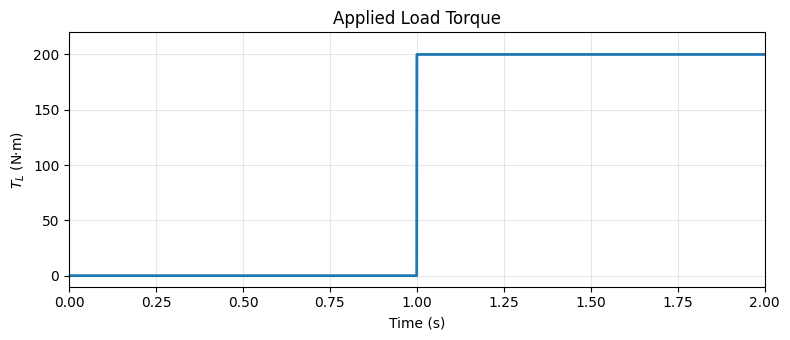

In [24]:
Tl_output = np.array([
    load_torque(t)
    for t in time
])

plt.figure(figsize=(8, 3.5))

plt.plot(
    time,
    Tl_output,
    linewidth=2
)

plt.xlabel("Time (s)")
plt.ylabel(r"$T_L$ (N·m)")
plt.title("Applied Load Torque")
plt.xlim(0, 2)
plt.ylim(-10, 220)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

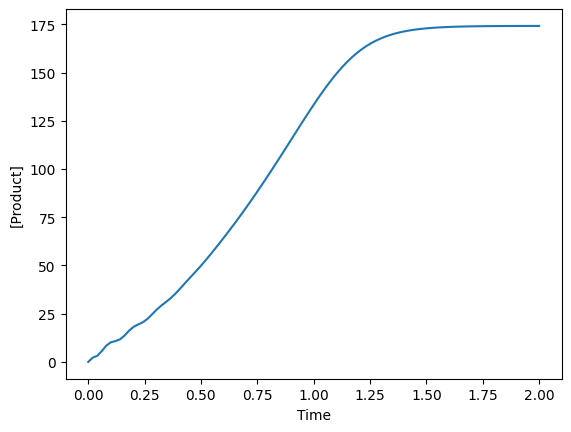

In [25]:
from autoreduce.utils import get_ODE
sys_ode = get_ODE(sys, timepoints_ode)
sol = sys_ode.solve_system().T

import matplotlib.pyplot as plt
plt.plot(timepoints_ode, np.transpose(np.array(C)@sol))
plt.xlabel('Time')
plt.ylabel('[Product]')
plt.show()

In [28]:
import numpy as np
import sympy as sp
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from scipy.integrate import odeint


reduced_models = [
    ("i<sub>sd</sub>, Ω", reduced_system_2d4),
    ("i<sub>sq</sub>, Ω", reduced_system_2d7),

    ("i<sub>sd</sub>, i<sub>sq</sub>, Ω", reduced_system_3d3),
    ("i<sub>sd</sub>, φ<sub>rd</sub>, Ω", reduced_system_3d5),
    ("i<sub>sd</sub>, φ<sub>rq</sub>, Ω", reduced_system_3d6),
    ("i<sub>sq</sub>, φ<sub>rd</sub>, Ω", reduced_system_3d8),
    ("i<sub>sq</sub>, φ<sub>rq</sub>, Ω", reduced_system_3d9),
    ("φ<sub>rd</sub>, φ<sub>rq</sub>, Ω", reduced_system_3d10),

    ("i<sub>sd</sub>, i<sub>sq</sub>, φ<sub>rd</sub>, Ω", reduced_system_4d2),
    ("i<sub>sd</sub>, i<sub>sq</sub>, φ<sub>rq</sub>, Ω", reduced_system_4d3),
    ("i<sub>sd</sub>, φ<sub>rd</sub>, φ<sub>rq</sub>, Ω", reduced_system_4d4),
    ("i<sub>sq</sub>, φ<sub>rd</sub>, φ<sub>rq</sub>, Ω", reduced_system_4d5)
]


timepoints_plot = np.asarray(time, dtype=float)

# Use the numerical odeint result, not symbolic Omega = x[4]
orig_output = np.asarray(
    solution[:, 4],
    dtype=float
).reshape(-1)


def load_torque(t):
    return 0.0 if t < 1.0 else 200.0


def solve_reduced_model(model, timepoints):
    state_symbols = list(model.x)
    parameter_symbols = list(model.params)

    numerical_f = sp.lambdify(
        state_symbols + parameter_symbols,
        list(model.f),
        modules="numpy"
    )

    if model.params_values is not None:
        parameter_values = np.asarray(
            model.params_values,
            dtype=float
        ).reshape(-1)
    else:
        parameter_values = np.asarray(
            params_values,
            dtype=float
        ).reshape(-1)

    initial_state = np.asarray(
        model.x_init,
        dtype=float
    ).reshape(-1)

    def rhs(state, t):
        current_parameters = parameter_values.copy()

        current_parameters[11] = load_torque(t)

        derivatives = numerical_f(
            *(list(state) + list(current_parameters))
        )

        derivatives = np.asarray(
            derivatives,
            dtype=float
        ).reshape(-1)

        if len(derivatives) != len(state):
            raise ValueError(
                f"Derivative length {len(derivatives)} "
                f"does not match state length {len(state)}."
            )

        if not np.all(np.isfinite(derivatives)):
            raise FloatingPointError(
                f"Non-finite derivative at t={t}."
            )

        return derivatives

    reduced_solution, solver_info = odeint(
        rhs,
        initial_state,
        timepoints,
        full_output=True,
        rtol=1e-8,
        atol=1e-10,
        mxstep=20000
    )

    if "successful" not in solver_info["message"].lower():
        raise RuntimeError(
            solver_info["message"]
        )

    if not np.all(np.isfinite(reduced_solution)):
        raise FloatingPointError(
            "Reduced solution contains NaN or infinity."
        )

    omega_index = None

    for i, state_symbol in enumerate(state_symbols):
        if str(state_symbol) == "x4":
            omega_index = i
            break

    if omega_index is not None:
        reduced_output = reduced_solution[:, omega_index]

    else:
        C_matrix = np.asarray(
            model.C,
            dtype=float
        )

        if C_matrix.ndim == 1:
            C_matrix = C_matrix.reshape(1, -1)

        reduced_output = np.ravel(
            C_matrix @ reduced_solution.T
        )

    reduced_output = np.asarray(
        reduced_output,
        dtype=float
    ).reshape(-1)

    return reduced_solution, reduced_output


reduced_results = []

for variable_name, model in reduced_models:
    try:
        reduced_solution, reduced_output = solve_reduced_model(
            model,
            timepoints_plot
        )

        if len(reduced_output) != len(orig_output):
            raise ValueError(
                f"Output length mismatch: "
                f"{len(reduced_output)} versus {len(orig_output)}"
            )

        error = orig_output - reduced_output

        mae = np.mean(np.abs(error))
        rmse = np.sqrt(np.mean(error**2))
        max_error = np.max(np.abs(error))

        reduced_results.append({
            "name": variable_name,
            "model": model,
            "solution": reduced_solution,
            "output": reduced_output,
            "mae": mae,
            "rmse": rmse,
            "max_error": max_error
        })

        print(
            f"{variable_name}: "
            f"MAE={mae:.6g}, "
            f"RMSE={rmse:.6g}, "
            f"Max error={max_error:.6g}"
        )

    except Exception as error:
        print(f"{variable_name} failed:")
        print(error)


if len(reduced_results) == 0:
    raise RuntimeError(
        "None of the reduced models simulated successfully."
    )


reduced_results.sort(
    key=lambda result: result["mae"]
)


mae_values = np.array(
    [result["mae"] for result in reduced_results],
    dtype=float
)


if np.isclose(mae_values.min(), mae_values.max()):
    normalized_errors = np.full(
        len(reduced_results),
        0.5
    )
else:
    normalized_errors = (
        mae_values - mae_values.min()
    ) / (
        mae_values.max() - mae_values.min()
    )


cmap = plt.colormaps["RdYlGn_r"]

fig = go.Figure()


fig.add_trace(
    go.Scatter(
        x=timepoints_plot,
        y=orig_output,
        mode="lines",
        name="Original ODE model",
        line=dict(
            color="black",
            dash="dot",
            width=4
        ),
        hovertemplate=(
            "Time: %{x:.4f} s"
            "<br>Speed: %{y:.4f} rad/s"
            "<extra>Original ODE model</extra>"
        )
    )
)


for result, normalized_error in zip(
    reduced_results,
    normalized_errors
):
    rgba = cmap(normalized_error)

    color = (
        f"rgb("
        f"{int(rgba[0] * 255)},"
        f"{int(rgba[1] * 255)},"
        f"{int(rgba[2] * 255)}"
        f")"
    )

    fig.add_trace(
        go.Scatter(
            x=timepoints_plot,
            y=result["output"],
            mode="lines",
            name=(
                f"{result['name']} | "
                f"MAE={result['mae']:.4g}"
            ),
            line=dict(
                color=color,
                width=2
            ),
            hovertemplate=(
                "Time: %{x:.4f} s"
                "<br>Speed: %{y:.4f} rad/s"
                f"<br>MAE: {result['mae']:.5g}"
                f"<br>RMSE: {result['rmse']:.5g}"
                "<extra></extra>"
            )
        )
    )


fig.add_vline(
    x=1.0,
    line_dash="dash",
    line_width=1.5,
    line_color="gray"
)


fig.add_annotation(
    x=1.0,
    y=1.0,
    xref="x",
    yref="paper",
    text="200 N·m load applied",
    showarrow=False,
    xanchor="left",
    yanchor="bottom"
)


fig.update_layout(
    title="Rotor Speed Ω: Original ODE Model vs. Reduced Models",
    xaxis_title="Time (s)",
    yaxis_title="Rotor Speed Ω (rad/s)",
    legend_title="Reduced systems sorted by MAE",
    template="plotly_white",
    width=1150,
    height=700,
    hovermode="x unified"
)


fig.update_xaxes(
    range=[0, 2]
)


fig.show()

i<sub>sd</sub>, Ω: MAE=2.65672, RMSE=4.57103, Max error=10.3182
i<sub>sq</sub>, Ω: MAE=2.97741, RMSE=5.11033, Max error=11.5303
i<sub>sd</sub>, i<sub>sq</sub>, Ω: MAE=2.83226, RMSE=4.86353, Max error=10.9467
i<sub>sd</sub>, φ<sub>rd</sub>, Ω: MAE=2.75797, RMSE=4.72629, Max error=10.5604
i<sub>sd</sub>, φ<sub>rq</sub>, Ω: MAE=2.40836, RMSE=4.16295, Max error=9.31867
i<sub>sq</sub>, φ<sub>rd</sub>, Ω: MAE=3.29738, RMSE=5.61072, Max error=12.5009
i<sub>sq</sub>, φ<sub>rq</sub>, Ω: MAE=2.94221, RMSE=5.04985, Max error=11.2768
φ<sub>rd</sub>, φ<sub>rq</sub>, Ω: MAE=2.60026, RMSE=4.48678, Max error=10.0064
i<sub>sd</sub>, i<sub>sq</sub>, φ<sub>rd</sub>, Ω: MAE=3.05014, RMSE=5.20616, Max error=11.5846
i<sub>sd</sub>, i<sub>sq</sub>, φ<sub>rq</sub>, Ω: MAE=2.69691, RMSE=4.64314, Max error=10.3492
i<sub>sd</sub>, φ<sub>rd</sub>, φ<sub>rq</sub>, Ω: MAE=2.4815, RMSE=4.27756, Max error=9.48829
i<sub>sq</sub>, φ<sub>rd</sub>, φ<sub>rq</sub>, Ω: MAE=2.53229, RMSE=4.37619, Max error=9.7712


It seems that the closest reduced models in terms of rotar mechanical speed is #3d6,#4d3,& #4d5. I've tweaked the code to where it will format the equations and display nicely.

In [27]:
import sympy as sp
from IPython.display import display, Math
from sympy import latex

# Symbols used inside equations
state_display = {
    x[0]: sp.Symbol(r"i_{sd}"),
    x[1]: sp.Symbol(r"i_{sq}"),
    x[2]: sp.Symbol(r"\phi_{rd}"),
    x[3]: sp.Symbol(r"\phi_{rq}"),
    x[4]: sp.Symbol(r"\Omega")
}

# Plain LaTeX labels used only for titles
state_labels = {
    x[0]: r"i_{sd}\;(\text{d-axis stator current})",
    x[1]: r"i_{sq}\;(\text{q-axis stator current})",
    x[2]: r"\phi_{rd}\;(\text{d-axis rotor flux})",
    x[3]: r"\phi_{rq}\;(\text{q-axis rotor flux})",
    x[4]: r"\Omega\;(\text{rotor mechanical speed})"
}

# Reduced models
reduced_models = [
    ("3d6", reduced_system_3d6),
    ("4d3", reduced_system_4d3),
    ("4d5", reduced_system_4d5)
]

# Original system
original_display = [
    equation.subs(state_display)
    for equation in f_symbolic
]

display(
    Math(
        r"\text{Original System: } "
        + latex(original_display)
    )
)

# Reduced systems
for name, model in reduced_models:

    # Build readable state label text
    state_string = r",\quad ".join(
        state_labels[state]
        for state in model.x
    )

    # Replace x0, x1, etc. inside equations
    display_functions = [
        equation.subs(state_display)
        for equation in model.f
    ]

    print(f"Reduced Model {name}")

    display(
        Math(
            r"\text{States: }\quad "
            + state_string
        )
    )

    display(
        Math(
            r"\text{Reduced Model " + name + r": }\quad "
            + latex(display_functions)
        )
    )

    print("-" * 60)

<IPython.core.display.Math object>

Reduced Model 3d6


<IPython.core.display.Math object>

<IPython.core.display.Math object>

------------------------------------------------------------
Reduced Model 4d3


...

<IPython.core.display.Math object>

------------------------------------------------------------
Reduced Model 4d5


<IPython.core.display.Math object>

<IPython.core.display.Math object>

------------------------------------------------------------


After replicating reduced model for Omega (Rotor Mechanical Speed) and 